In [ ]:
import fastf1 as ff1
from fastf1 import plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import os

os.chdir('/Users/jackson/Documents/ECON570')

In [2]:
import pandas as pd

financial_data = pd.read_csv('F1/f1_financial_data.csv')  # Load all sheets

# Display available sheets and preview first few rows of each
financial_data

,Team,Legal Entity,Country,Year,Revenue (£m),Operating Profit (£m),Net Income (£m),Prize Money (£m),Employees,Source
0,Red Bull Racing,Red Bull Technology Ltd,UK,2019,250,4,3,150,890,Companies House (RBTL)
1,Red Bull Racing,Red Bull Technology Ltd,UK,2020,245,2,1,145,875,NaN
2,Red Bull Racing,Red Bull Technology Ltd,UK,2021,285,5,4,160,890,NaN
3,Red Bull Racing,Red Bull Technology Ltd,UK,2022,304,6,5,165,910,NaN
4,Red Bull Racing,Red Bull Technology Ltd,UK,2023,317,7,6,170,915,NaN
5,Mercedes,Mercedes-Benz Grand Prix Ltd,UK,2019,363,18,13,177,1020,Companies House
6,Mercedes,Mercedes-Benz Grand Prix Ltd,UK,2020,355,16,11,165,980,NaN
7,Mercedes,Mercedes-Benz Grand Prix Ltd,UK,2021,385,22,16,180,1040,NaN
8,Mercedes,Mercedes-Benz Grand Prix Ltd,UK,2022,375,19,14,175,1015,NaN
9,Mercedes,Mercedes-Benz Grand Prix Ltd,UK,2023,362,15,12,165,1000,NaN


In [13]:
financial_data.reset_index(inplace=True)


In [3]:
financial_data = financial_data[
    ~financial_data["Team"].str.contains("Sauber", case=False, na=False) &
    ~financial_data["Legal Entity"].str.contains("Sauber", case=False, na=False)
]
financial_data

,Team,Legal Entity,Country,Year,Revenue (£m),Operating Profit (£m),Net Income (£m),Prize Money (£m),Employees,Source
0,Red Bull Racing,Red Bull Technology Ltd,UK,2019,250,4,3,150,890,Companies House (RBTL)
1,Red Bull Racing,Red Bull Technology Ltd,UK,2020,245,2,1,145,875,NaN
2,Red Bull Racing,Red Bull Technology Ltd,UK,2021,285,5,4,160,890,NaN
3,Red Bull Racing,Red Bull Technology Ltd,UK,2022,304,6,5,165,910,NaN
4,Red Bull Racing,Red Bull Technology Ltd,UK,2023,317,7,6,170,915,NaN
5,Mercedes,Mercedes-Benz Grand Prix Ltd,UK,2019,363,18,13,177,1020,Companies House
6,Mercedes,Mercedes-Benz Grand Prix Ltd,UK,2020,355,16,11,165,980,NaN
7,Mercedes,Mercedes-Benz Grand Prix Ltd,UK,2021,385,22,16,180,1040,NaN
8,Mercedes,Mercedes-Benz Grand Prix Ltd,UK,2022,375,19,14,175,1015,NaN
9,Mercedes,Mercedes-Benz Grand Prix Ltd,UK,2023,362,15,12,165,1000,NaN


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
core           INFO 	Loading data for Saudi Arabian Grand Pri

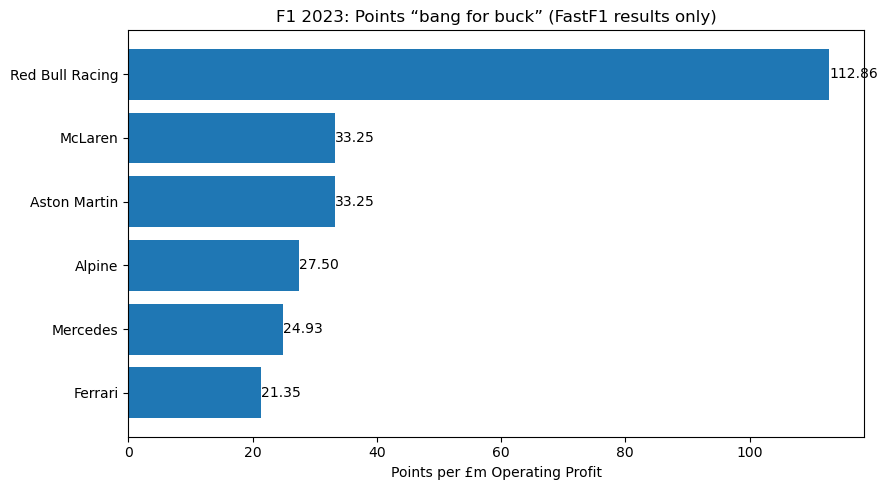

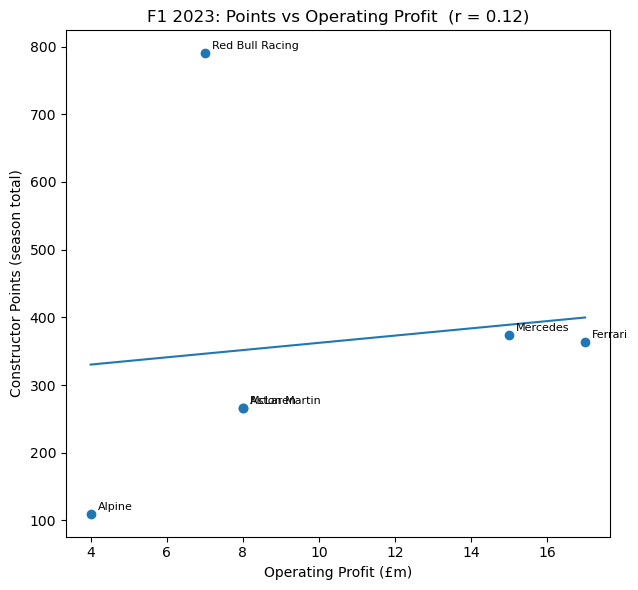

           Team  Points  Operating Profit (£m)  Points per £m Profit
Red Bull Racing   790.0                      7            112.857143
   Aston Martin   266.0                      8             33.250000
        McLaren   266.0                      8             33.250000
         Alpine   110.0                      4             27.500000
       Mercedes   374.0                     15             24.933333
        Ferrari   363.0                     17             21.352941


In [ ]:


# ---------- config ----------
CACHE_DIR = '/Users/jackson/Documents/ECON570/F1'
FIN_PATH  = '/Users/jackson/Documents/ECON570/F1/f1_financial_data.csv'
YEAR      = 2023                   
MAX_ROUNDS = 30                    
MISS_LIMIT = 5                     
SLEEP_ON_FAIL_S = 1.0

# FastF1 cache
os.makedirs(CACHE_DIR, exist_ok=True)
fastf1.Cache.enable_cache(CACHE_DIR)

# ---------- helper: load a race session safely ----------
def load_race(year: int, rnd: int) -> Session | None:
    try:
        ses = fastf1.get_session(year, rnd, 'R')
        ses.load()  # pulls results table
        return ses
    except Exception as e:
       
        time.sleep(SLEEP_ON_FAIL_S)
        return None

# ---------- gather points from all successful race loads ----------
all_pts = []
misses = 0
for rnd in range(1, MAX_ROUNDS + 1):
    ses = load_race(YEAR, rnd)
    if ses is None:
        misses += 1
        if misses >= MISS_LIMIT:
            break
        continue
    misses = 0
    res = ses.results
    if res is None or res.empty:
        continue
    df_rnd = res[['TeamName', 'Points']].copy()
    # Some results may have NaN points for DNQ/DNS; treat as 0
    df_rnd['Points'] = pd.to_numeric(df_rnd['Points'], errors='coerce').fillna(0.0)
    all_pts.append(df_rnd)

if not all_pts:
    raise RuntimeError("No race results loaded. Check internet, cache, or YEAR.")

points_season = (pd.concat(all_pts, ignore_index=True)
                   .groupby('TeamName', as_index=False)['Points'].sum())

# ---------- map FastF1 team names to your financial CSV names ----------
name_map = {
    'Red Bull Racing': 'Red Bull Racing',
    'Mercedes': 'Mercedes',
    'Ferrari': 'Ferrari',
    'McLaren': 'McLaren',
    'Alpine': 'Alpine',
    'Aston Martin': 'Aston Martin',
}
points_season['Team'] = points_season['TeamName'].map(name_map)
points_season = points_season.dropna(subset=['Team'])

# ---------- load financials and merge ----------
fin = financial_data.copy()
fin_y = fin[fin['Year'] == YEAR].copy()

merged = pd.merge(points_season[['Team','Points']],
                  fin_y,
                  on='Team',
                  how='inner')

# clean and compute
merged['Operating Profit (£m)'] = pd.to_numeric(merged['Operating Profit (£m)'], errors='coerce')
merged = merged.dropna(subset=['Points','Operating Profit (£m)'])
merged = merged[merged['Operating Profit (£m)'] != 0]  # avoid div/0
merged['Points per £m Profit'] = merged['Points'] / merged['Operating Profit (£m)']

# ---------- visualize: bang-for-buck ----------
plt.figure(figsize=(9,5))
order = merged.sort_values('Points per £m Profit', ascending=True)
plt.barh(order['Team'], order['Points per £m Profit'])
for i, v in enumerate(order['Points per £m Profit']):
    plt.text(v, i, f'{v:.2f}', ha='left', va='center')
plt.xlabel('Points per £m Operating Profit')
plt.title(f'F1 {YEAR}: Points “bang for buck” (FastF1 results only)')
plt.tight_layout()
plt.show()

# ---------- visualize: correlation ----------
x = merged['Operating Profit (£m)'].astype(float).to_numpy()
y = merged['Points'].astype(float).to_numpy()
r = np.corrcoef(x, y)[0,1]

plt.figure(figsize=(6.5,6))
plt.scatter(x, y)
# best-fit
m, b = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 100)
plt.plot(xx, m*xx + b)
for _, row in merged.iterrows():
    plt.annotate(row['Team'], (row['Operating Profit (£m)'], row['Points']),
                 textcoords='offset points', xytext=(5,3), fontsize=8)
plt.xlabel('Operating Profit (£m)')
plt.ylabel('Constructor Points (season total)')
plt.title(f'F1 {YEAR}: Points vs Operating Profit  (r = {r:.2f})')
plt.tight_layout()
plt.show()

print(merged[['Team','Points','Operating Profit (£m)','Points per £m Profit']]
      .sort_values('Points per £m Profit', ascending=False)
      .to_string(index=False))
